# XGBoost 실험: 2017~2024 학습 → 2025 포스트시즌 예측 검증

**목표:** 2017~2024 일별 데이터로 XGBoost를 학습하고, 2025 시즌 실제 결과와 비교

**평가 방법:** 시즌 진행 시점(50% / 75% / 90% / 최종)별로 상위 5팀 예측 적중률 확인

In [1]:
import sys
sys.path.append("../../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
from src.utils.config import FEATURE_COLS

df = pd.read_csv("../../../data/modeling/train_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

train = df[df["season"] != 2025].copy()   # 2017~2024 학습
test  = df[df["season"] == 2025].copy()   # 2025 검증

print(f"학습 데이터: {train.shape}  ({sorted(train['season'].unique())})")
print(f"테스트 데이터: {test.shape}   (2025)")
print(f"\n피처 수: {len(FEATURE_COLS)}개")
print(f"결측치 — 학습: {train[FEATURE_COLS].isna().sum().sum()}  테스트: {test[FEATURE_COLS].isna().sum().sum()}")

학습 데이터: (12792, 93)  ([np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)])
테스트 데이터: (1630, 93)   (2025)

피처 수: 27개
결측치 — 학습: 14436  테스트: 1446


In [3]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

X_train = train[FEATURE_COLS]
y_train = train["postseason"]
X_test  = test[FEATURE_COLS]
y_test  = test["postseason"]

# 최근 시즌 + 시즌 후반 가중치
s_min, s_max = train["season"].min(), train["season"].max()
season_w = 0.3 + 0.7 * (train["season"] - s_min) / (s_max - s_min)
stage_w  = 0.4 + 0.6 * train["games_played_ratio"]
sample_weights = (season_w * stage_w).values

# ── 1. XGBoost ──────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric="logloss", random_state=42,
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)

# ── 2. LightGBM ─────────────────────────────────────────────
lgbm = LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, min_child_samples=20,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    random_state=42, verbose=-1,
)
lgbm.fit(X_train, y_train, sample_weight=sample_weights)

# ── 3. Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=20,
    max_features="sqrt", class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train, sample_weight=sample_weights)

print("세 모델 학습 완료: XGBoost / LightGBM / Random Forest")

세 모델 학습 완료: XGBoost / LightGBM / Random Forest


In [4]:
## 세 모델 + 앙상블 예측 확률 계산
test = test.copy()

# 각 모델 원시 확률
test["prob_xgb"]  = xgb.predict_proba(X_test)[:, 1]
test["prob_lgbm"] = lgbm.predict_proba(X_test)[:, 1]
test["prob_rf"]   = rf.predict_proba(X_test)[:, 1]

# 앙상블: 세 모델 평균
test["prob_ensemble"] = (test["prob_xgb"] + test["prob_lgbm"] + test["prob_rf"]) / 3

# 스냅샷 내 상대 확률 정규화 (10팀 합 → 5)
def normalize_prob(df, col):
    return (
        df.groupby("date")[col]
        .transform(lambda x: x / x.sum() * 5)
        .clip(upper=1.0)
    )

for col in ["prob_xgb", "prob_lgbm", "prob_rf", "prob_ensemble"]:
    test[f"{col}_norm"] = normalize_prob(test, col)

## 시점별 적중률 비교
checkpoints = {
    "50% (72경기)":   0.50,
    "75% (108경기)":  0.75,
    "90% (130경기)":  0.90,
    "최종 (144경기)": 1.00,
}
models = {
    "XGBoost":    "prob_xgb_norm",
    "LightGBM":   "prob_lgbm_norm",
    "RandForest": "prob_rf_norm",
    "Ensemble":   "prob_ensemble_norm",
}

actual_top5 = set(test[test["postseason"] == 1]["team"].unique())
print(f"2025 실제 포스트시즌: {sorted(actual_top5)}\n")

header = f"{'시점':<16}" + "".join(f"{m:>12}" for m in models)
print(header)
print("-" * (16 + 12 * len(models)))

for label, ratio in checkpoints.items():
    snapshot = test[test["games_played_ratio"] <= ratio]
    latest   = snapshot.sort_values("date").groupby("team").last().reset_index()
    row = f"{label:<16}"
    for m_name, prob_col in models.items():
        top5 = set(latest.nlargest(5, prob_col)["team"])
        hit  = len(top5 & actual_top5)
        row += f"     {hit}/5   "
    print(row)

# 최종 앙상블 확률 저장 (이후 차트용)
test["prob"] = test["prob_ensemble_norm"]

2025 실제 포스트시즌: ['LG', 'NC', 'SSG', '삼성', '한화']

시점                   XGBoost    LightGBM  RandForest    Ensemble
----------------------------------------------------------------
50% (72경기)           3/5        3/5        3/5        3/5   
75% (108경기)          3/5        3/5        3/5        3/5   
90% (130경기)          4/5        4/5        4/5        4/5   
최종 (144경기)           5/5        5/5        5/5        5/5   


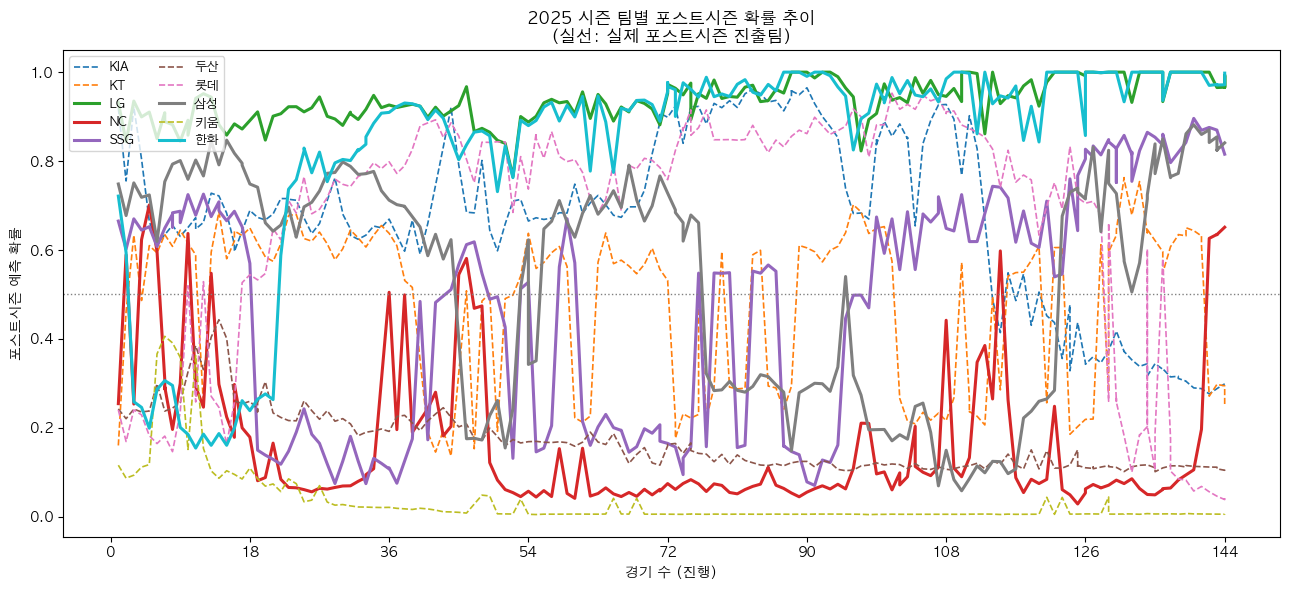

In [5]:
## 시즌 전체 예측 확률 추이 (팀별)
fig, ax = plt.subplots(figsize=(13, 6))

teams = test["team"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(teams)))

for team, color in zip(teams, colors):
    t = test[test["team"] == team].sort_values("games_played_ratio")
    ls = "-" if team in actual_top5 else "--"
    lw = 2.2 if team in actual_top5 else 1.2
    ax.plot(t["games_played_ratio"] * 144, t["prob"], label=team,
            color=color, linestyle=ls, linewidth=lw)

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("경기 수 (진행)")
ax.set_ylabel("포스트시즌 예측 확률")
ax.set_title("2025 시즌 팀별 포스트시즌 확률 추이\n(실선: 실제 포스트시즌 진출팀)")
ax.legend(loc="upper left", ncol=2, fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(18))
plt.tight_layout()
plt.show()

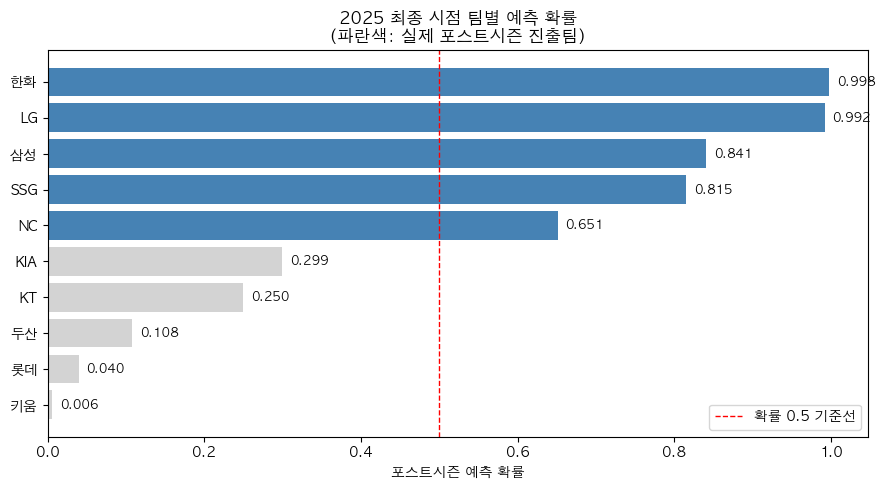

In [6]:
## 최종 시점 예측 확률 순위 (바 차트)
final = test.sort_values("date").groupby("team").last().reset_index()
final = final.sort_values("prob", ascending=True)

colors_bar = ["steelblue" if t in actual_top5 else "lightgray" for t in final["team"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(final["team"], final["prob"], color=colors_bar)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="확률 0.5 기준선")
ax.set_xlabel("포스트시즌 예측 확률")
ax.set_title("2025 최종 시점 팀별 예측 확률\n(파란색: 실제 포스트시즌 진출팀)")
ax.legend()
for bar, val in zip(bars, final["prob"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
## 앙상블 분류 성능 (전체 2025 일별 행 기준)
from sklearn.metrics import classification_report, roc_auc_score

y_pred_ens = (test["prob_ensemble"] >= 0.5).astype(int)
y_prob_ens = test["prob_ensemble"]

print("=== 앙상블 분류 리포트 (일별 행 기준) ===")
print(classification_report(y_test, y_pred_ens, target_names=["비진출", "포스트시즌"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ens):.4f}")

=== 앙상블 분류 리포트 (일별 행 기준) ===
              precision    recall  f1-score   support

         비진출       0.62      0.56      0.59       815
       포스트시즌       0.60      0.66      0.63       815

    accuracy                           0.61      1630
   macro avg       0.61      0.61      0.61      1630
weighted avg       0.61      0.61      0.61      1630

ROC-AUC: 0.6840


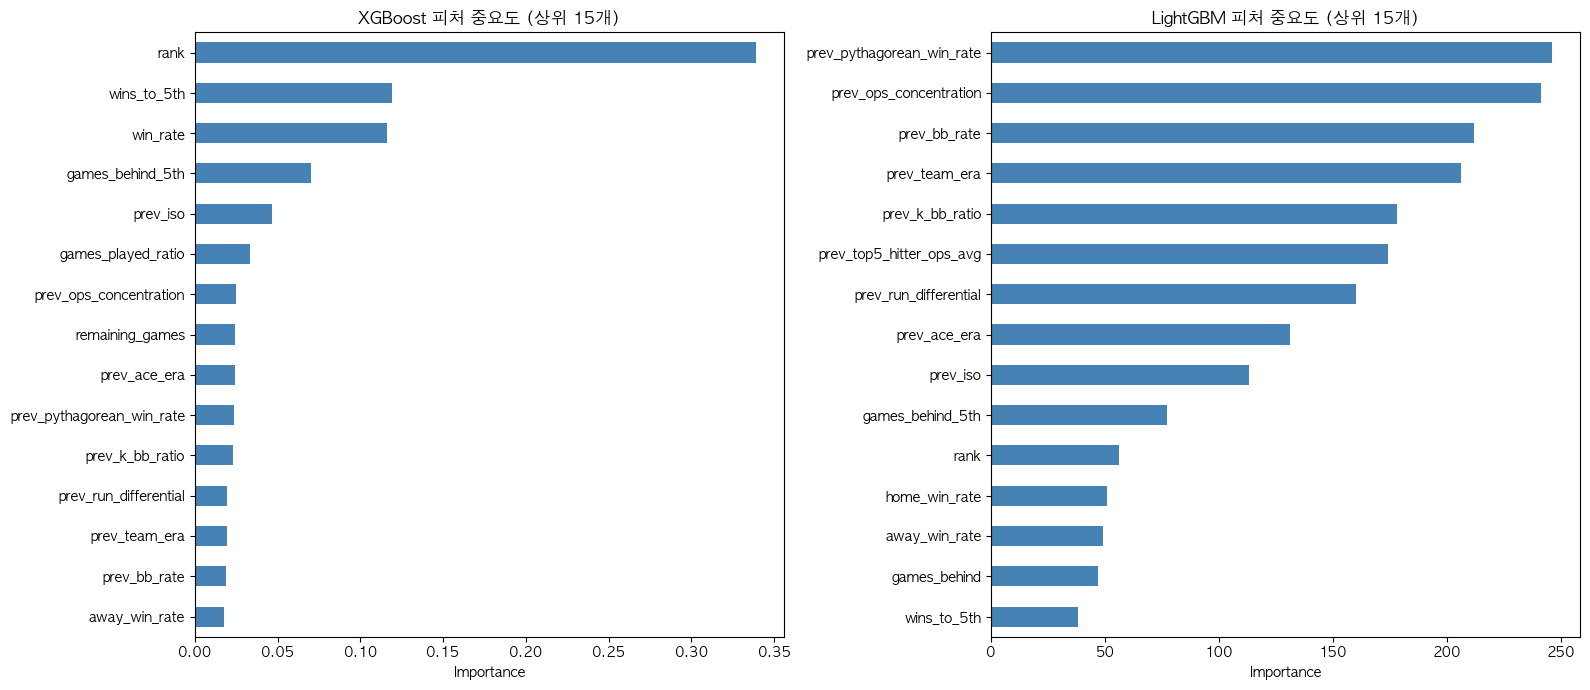

In [8]:
## 피처 중요도 비교 (XGBoost vs LightGBM, 각 상위 15개)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, m) in zip(axes, [("XGBoost", xgb), ("LightGBM", lgbm)]):
    imp = pd.Series(m.feature_importances_, index=FEATURE_COLS)
    imp.sort_values(ascending=True).tail(15).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} 피처 중요도 (상위 15개)")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()